## Задание 1

In [1]:
import torch
from torchvision import datasets, transforms

# преобразование в тензор
transform = transforms.ToTensor()

# загрузка train датасета
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# загрузка test датасета
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset), len(test_dataset))

100.0%
100.0%
100.0%
100.0%

60000 10000


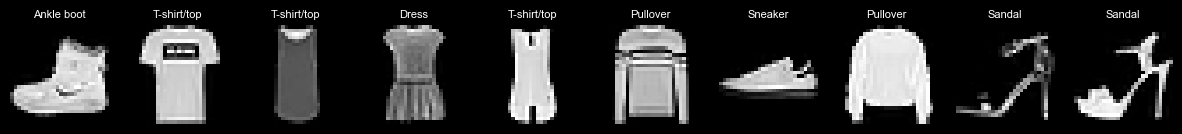

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.style.use("dark_background")

clases = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(clases[label], fontsize=8)
    axes[i].axis("off")

plt.show()

In [5]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

print(len(train_subset), len(val_subset))

48000 12000


In [7]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(len(train_loader), len(val_loader), len(test_loader))

375 94 79


In [8]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.model(x)

model = MLP()
print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

print(device)

mps


In [12]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [13]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Это слабый baseline, для того, чтобы посмотреть что все работает

In [14]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

100%|██████████| 375/375 [00:03<00:00, 117.38it/s]


Epoch 1: Train Loss=0.6662, Train Acc=0.7704 | Val Loss=0.4518, Val Acc=0.8433


100%|██████████| 375/375 [00:01<00:00, 241.46it/s]


Epoch 2: Train Loss=0.4395, Train Acc=0.8450 | Val Loss=0.4274, Val Acc=0.8442


100%|██████████| 375/375 [00:01<00:00, 242.60it/s]


Epoch 3: Train Loss=0.3927, Train Acc=0.8587 | Val Loss=0.4023, Val Acc=0.8549


100%|██████████| 375/375 [00:01<00:00, 239.58it/s]


Epoch 4: Train Loss=0.3626, Train Acc=0.8681 | Val Loss=0.3688, Val Acc=0.8648


100%|██████████| 375/375 [00:01<00:00, 240.48it/s]


Epoch 5: Train Loss=0.3431, Train Acc=0.8750 | Val Loss=0.3486, Val Acc=0.8721


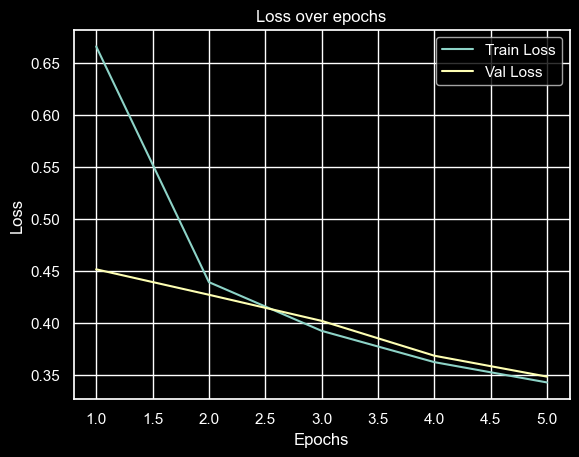

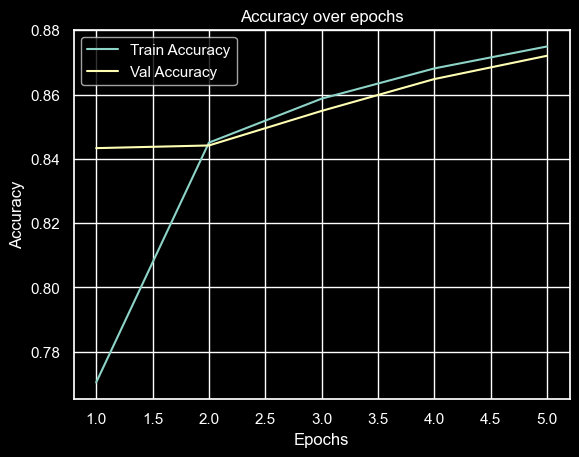

In [15]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

### Вот это уже reference для сравнения в будущем

In [16]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=15
)

100%|██████████| 375/375 [00:01<00:00, 235.13it/s]


Epoch 1: Train Loss=0.3258, Train Acc=0.8806 | Val Loss=0.3414, Val Acc=0.8731


100%|██████████| 375/375 [00:01<00:00, 240.46it/s]


Epoch 2: Train Loss=0.3083, Train Acc=0.8863 | Val Loss=0.3409, Val Acc=0.8752


100%|██████████| 375/375 [00:01<00:00, 240.78it/s]


...

Epoch 13: Train Loss=0.2174, Train Acc=0.9183 | Val Loss=0.2931, Val Acc=0.8955


100%|██████████| 375/375 [00:01<00:00, 238.91it/s]


Epoch 14: Train Loss=0.2102, Train Acc=0.9204 | Val Loss=0.2978, Val Acc=0.8952


100%|██████████| 375/375 [00:01<00:00, 238.35it/s]


Epoch 15: Train Loss=0.2043, Train Acc=0.9225 | Val Loss=0.3203, Val Acc=0.8868


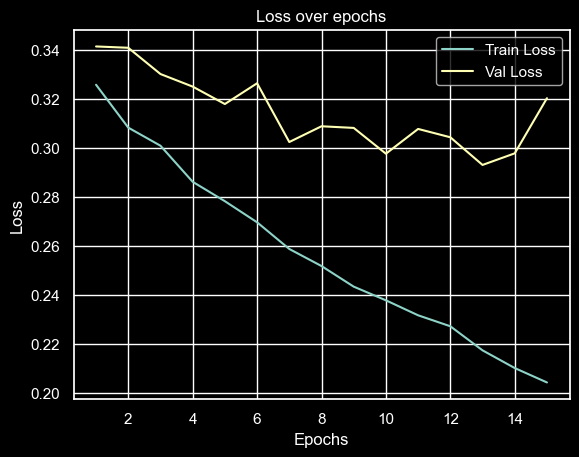

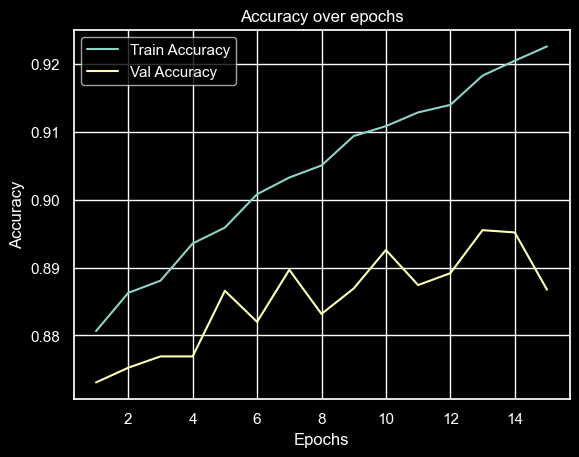

In [17]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

## Выводы по заданию 1:

#### модель обучается, все вроде бы хорошо, но на валидационной выборке лосс и точность нестабильны. Значит это потолок архитектуры. 

## Задание 2

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [19]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

100%|██████████| 375/375 [00:02<00:00, 126.13it/s]


Epoch 1: Train Loss=0.6914, Train Acc=0.7510 | Val Loss=0.5166, Val Acc=0.8015


100%|██████████| 375/375 [00:02<00:00, 176.85it/s]


Epoch 2: Train Loss=0.4359, Train Acc=0.8401 | Val Loss=0.3927, Val Acc=0.8563


100%|██████████| 375/375 [00:02<00:00, 156.10it/s]


Epoch 3: Train Loss=0.3827, Train Acc=0.8599 | Val Loss=0.3519, Val Acc=0.8704


100%|██████████| 375/375 [00:02<00:00, 133.76it/s]


Epoch 4: Train Loss=0.3476, Train Acc=0.8733 | Val Loss=0.3276, Val Acc=0.8792


100%|██████████| 375/375 [00:02<00:00, 164.12it/s]


Epoch 5: Train Loss=0.3207, Train Acc=0.8821 | Val Loss=0.3083, Val Acc=0.8856


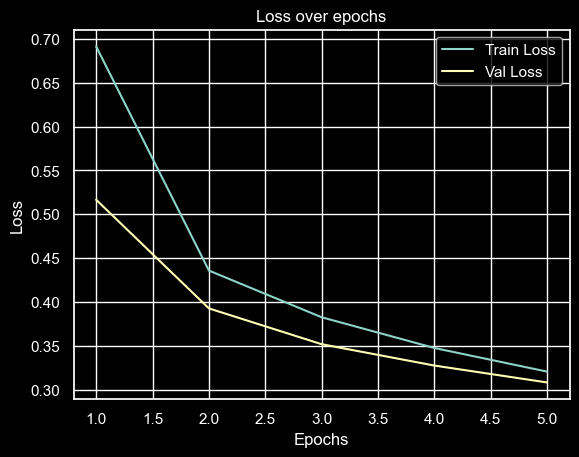

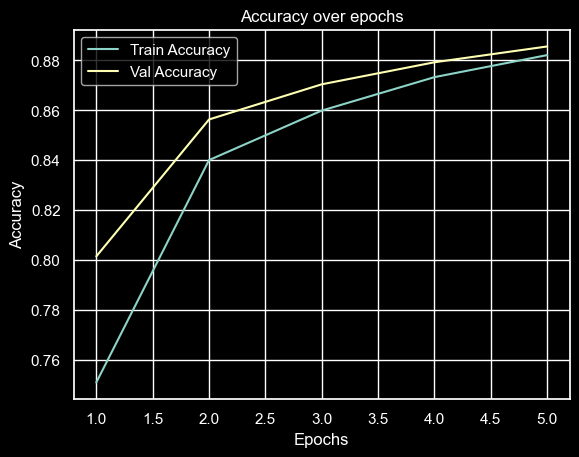

In [20]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

### Мини вывод после baseline:

#### CNN за 5 эпох достигла +- тех же показателей что и MLP за 15 эпох.
Я понимаю что сравнивать модели на разном кол-ве эпох странно, то все-таки это интресное наблюдения (для меня).

In [21]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=15
)

100%|██████████| 375/375 [00:03<00:00, 120.39it/s]


Epoch 1: Train Loss=0.3007, Train Acc=0.8909 | Val Loss=0.3039, Val Acc=0.8892


100%|██████████| 375/375 [00:02<00:00, 148.15it/s]


Epoch 2: Train Loss=0.2851, Train Acc=0.8950 | Val Loss=0.2902, Val Acc=0.8908


100%|██████████| 375/375 [00:02<00:00, 166.95it/s]


...

Epoch 13: Train Loss=0.1702, Train Acc=0.9371 | Val Loss=0.2462, Val Acc=0.9102


100%|██████████| 375/375 [00:02<00:00, 175.89it/s]


Epoch 14: Train Loss=0.1598, Train Acc=0.9408 | Val Loss=0.2515, Val Acc=0.9093


100%|██████████| 375/375 [00:02<00:00, 181.83it/s]


Epoch 15: Train Loss=0.1538, Train Acc=0.9423 | Val Loss=0.2427, Val Acc=0.9128


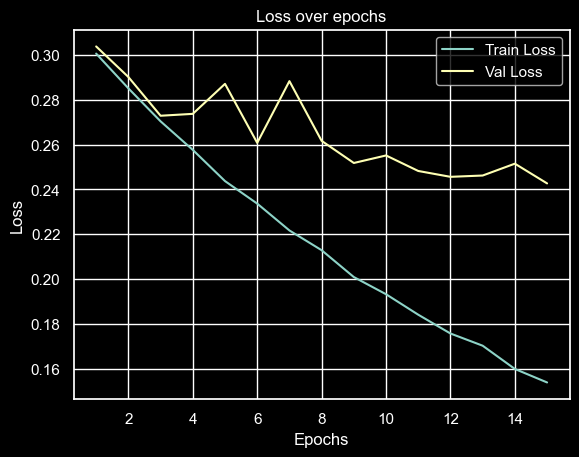

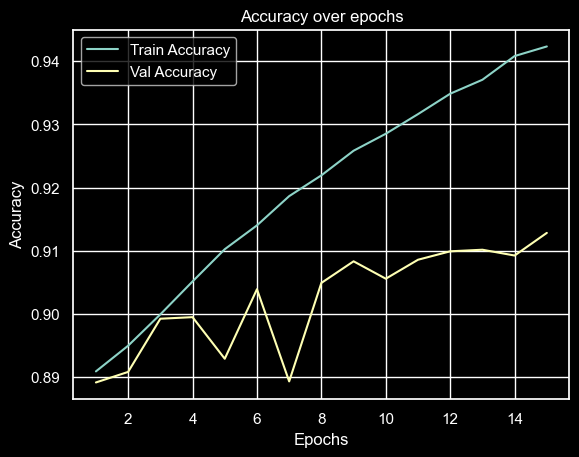

In [22]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

## Вывод по заданию 2:

#### Модель обучается лучше, по графикам видно что есть небольшое переобучение. В целом accuracy возросла на 2% (MLP: 89%, CNN: 91%). CNN как будто бы сильно лучше справляется с задачей, что в принципе неудивительно.

## Задание 3

In [23]:
from torchvision import transforms
from torchvision import datasets

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

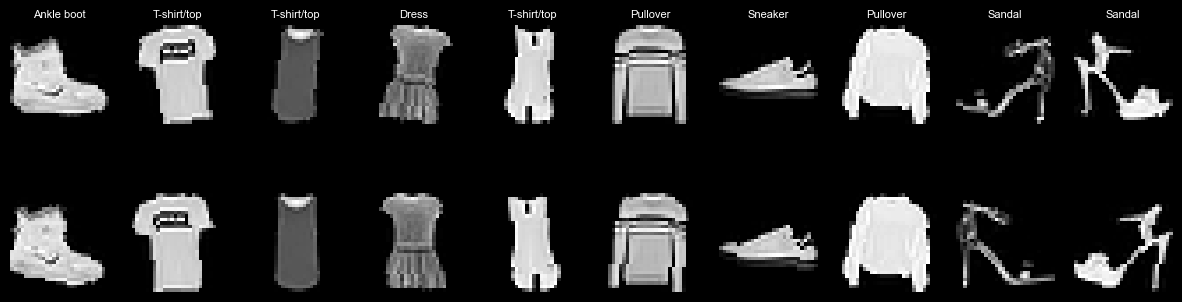

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.style.use("dark_background")

classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    img, label = train_dataset[i]

    axes[0, i].imshow(img.squeeze(), cmap="gray")
    axes[0, i].set_title(classes[label], fontsize=8)
    axes[0, i].axis("off")

    img2, _ = train_dataset[i]
    axes[1, i].imshow(img2.squeeze(), cmap="gray")
    axes[1, i].axis("off")

plt.show()

In [25]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

batch_size = 128

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(len(train_loader), len(val_loader))

375 94


In [26]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=15
)

100%|██████████| 375/375 [00:03<00:00, 116.43it/s]


Epoch 1: Train Loss=0.3409, Train Acc=0.8785 | Val Loss=0.2991, Val Acc=0.8902


100%|██████████| 375/375 [00:03<00:00, 118.88it/s]


Epoch 2: Train Loss=0.2758, Train Acc=0.8964 | Val Loss=0.2711, Val Acc=0.9002


100%|██████████| 375/375 [00:03<00:00, 122.47it/s]


...

Epoch 13: Train Loss=0.2045, Train Acc=0.9226 | Val Loss=0.2441, Val Acc=0.9129


100%|██████████| 375/375 [00:03<00:00, 121.65it/s]


Epoch 14: Train Loss=0.2047, Train Acc=0.9223 | Val Loss=0.2513, Val Acc=0.9129


100%|██████████| 375/375 [00:03<00:00, 121.66it/s]


Epoch 15: Train Loss=0.1968, Train Acc=0.9266 | Val Loss=0.2503, Val Acc=0.9123


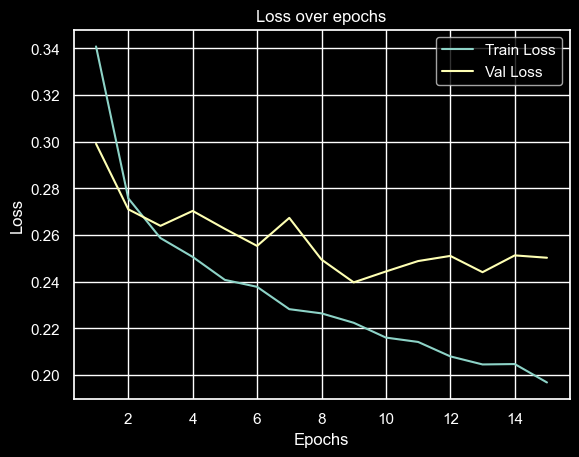

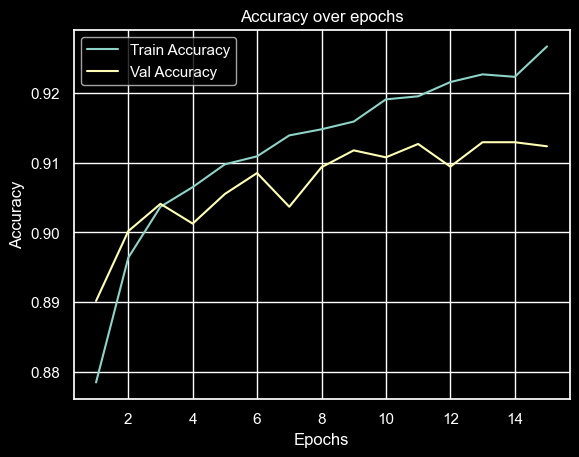

In [27]:
epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")
plt.legend()
plt.show()

## Выводы по заданию 3

#### Аугментация не увеличила accuracy модели (всего лишь + 1%), но она добавила стабильности. Те сейчас модель переобучается меньше, чем тогда, когда аугментации не было. В принципе вывод был прогназируемым.